In [ ]:
# Notebook 12
# Kigali Transfer Learning
#
# Objective:
# Fine-tune the SONYC-adapted CNN using Kigali recordings
# to create the final Urban Noise Governance model.

In [11]:
# Import libraries

from pathlib import Path

import numpy as np
import pandas as pd

import librosa

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

import joblib

In [12]:
# Google Drive paths

PROJECT_DIR = Path("/content/drive/MyDrive/UrbanNoiseProject")

DATASET_DIR = PROJECT_DIR / "datasets"

MODELS_DIR = PROJECT_DIR / "models"

OUTPUT_DIR = PROJECT_DIR / "output"

In [13]:
# Kigali dataset path

KIGALI_DIR = DATASET_DIR / "Kigali_Data"

print(KIGALI_DIR)

/content/drive/MyDrive/UrbanNoiseProject/datasets/Kigali_Data


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Verify Kigali dataset

classes = sorted([

    folder.name

    for folder in KIGALI_DIR.iterdir()

    if folder.is_dir()

])

print(classes)

['Ambience', 'Constuction', 'Entertainment', 'Traffic', 'Worship']


In [16]:
# Count recordings

counts = {}

for folder in classes:

    n = len(list((KIGALI_DIR / folder).glob("*.wav")))

    counts[folder] = n

pd.DataFrame.from_dict(

    counts,

    orient="index",

    columns=["Recordings"]

)

,Recordings
Ambience,102
Constuction,129
Entertainment,130
Traffic,119
Worship,109


In [17]:
# Mel Spectrogram extraction

def extract_features(audio_path):

    audio, sr = librosa.load(

        audio_path,

        sr=22050

    )

    mel = librosa.feature.melspectrogram(

        y=audio,

        sr=sr,

        n_mels=128

    )

    mel_db = librosa.power_to_db(

        mel,

        ref=np.max

    )

    if mel_db.shape[1] < 128:

        pad = 128 - mel_db.shape[1]

        mel_db = np.pad(

            mel_db,

            ((0,0),(0,pad))

        )

    else:

        mel_db = mel_db[:, :128]

    return mel_db

In [18]:
# Build Kigali dataset

X = []

y = []

for label in classes:

    folder = KIGALI_DIR / label

    for file in folder.glob("*.wav"):

        try:

            feature = extract_features(file)

            X.append(feature)

            y.append(label)

        except Exception:

            continue

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(589, 128, 128)
(589,)


In [19]:
# Encode Kigali labels

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

joblib.dump(

    encoder,

    MODELS_DIR / "kigali_label_encoder.pkl"

)

print(encoder.classes_)

['Ambience' 'Constuction' 'Entertainment' 'Traffic' 'Worship']


In [20]:
# Split Kigali dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)

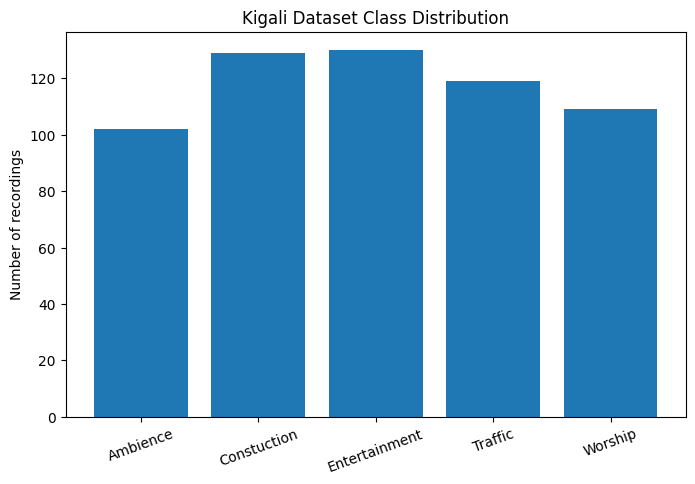

In [21]:
# Kigali class distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(counts.keys(), counts.values())

plt.title("Kigali Dataset Class Distribution")

plt.ylabel("Number of recordings")

plt.xticks(rotation=20)

plt.show()

In [22]:
# Prepare CNN input

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training shape :", X_train.shape)
print("Testing shape  :", X_test.shape)

Training shape : (471, 128, 128, 1)
Testing shape  : (118, 128, 128, 1)


In [23]:
# Load SONYC transfer model

transfer_model = load_model(
    MODELS_DIR / "urban_noise_sonyc.keras"
)

transfer_model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sonyc_classifier (Dense)        │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,121 (434.07 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 109,184 (426.50 KB)

 Optimizer params: 1,292 (5.05 KB)

In [24]:
# Freeze pretrained layers

for layer in transfer_model.layers[:-1]:
    layer.trainable = False

transfer_model.layers[-1].trainable = True

In [25]:
# Verify trainable layers

transfer_model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sonyc_classifier (Dense)        │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,121 (434.07 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 109,184 (426.50 KB)

 Optimizer params: 1,292 (5.05 KB)

In [26]:
# Compile model

transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [27]:
# Fine-tune on Kigali

history = transfer_model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    verbose=1

)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 487ms/step - accuracy: 0.3803 - loss: 1.6242 - val_accuracy: 0.4000 - val_loss: 1.5926
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.3830 - loss: 1.6039 - val_accuracy: 0.4211 - val_loss: 1.5732
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.3803 - loss: 1.5891 - val_accuracy: 0.4211 - val_loss: 1.5545
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 538ms/step - accuracy: 0.3590 - loss: 1.6002 - val_accuracy: 0.4105 - val_loss: 1.5359
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.3989 - loss: 1.5830 - val_accuracy: 0.4211 - val_loss: 1.5181
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - accuracy: 0.4043 - loss: 1.5131 - val_accuracy: 0.4316 - val_loss: 1.5009
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 527ms/step - accuracy: 0.3830 - loss: 1.5132 - val_accuracy: 0.4316 - val_loss: 1.4842
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 396ms/step - accuracy: 0.4521 - loss: 1.4840 - val_accuracy: 0.

In [28]:
# Evaluate Kigali model

test_loss, test_accuracy = transfer_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.4746 - loss: 1.2758

Test Accuracy : 0.4746
Test Loss     : 1.2758


In [29]:
# Predict Kigali test set

import numpy as np

predictions = transfer_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

print("Predictions generated.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step
Predictions generated.


In [30]:
# Classification Report

from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        y_pred,

        target_names=encoder.classes_

    )

)

               precision    recall  f1-score   support

     Ambience       0.00      0.00      0.00        20
  Constuction       0.55      0.81      0.66        26
Entertainment       0.00      0.00      0.00        26
      Traffic       0.31      0.54      0.39        24
      Worship       0.69      1.00      0.81        22

     accuracy                           0.47       118
    macro avg       0.31      0.47      0.37       118
 weighted avg       0.31      0.47      0.38       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


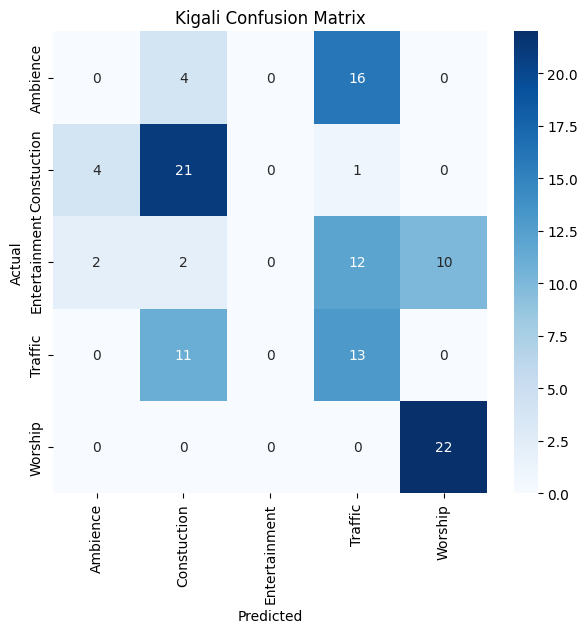

In [31]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Kigali Confusion Matrix")

plt.show()

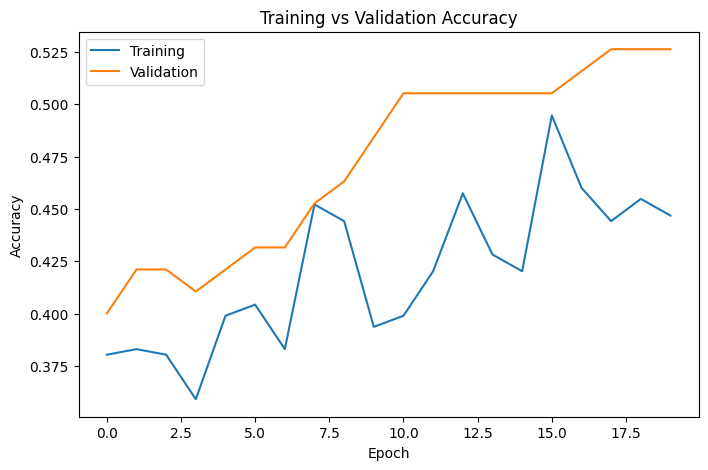

In [32]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

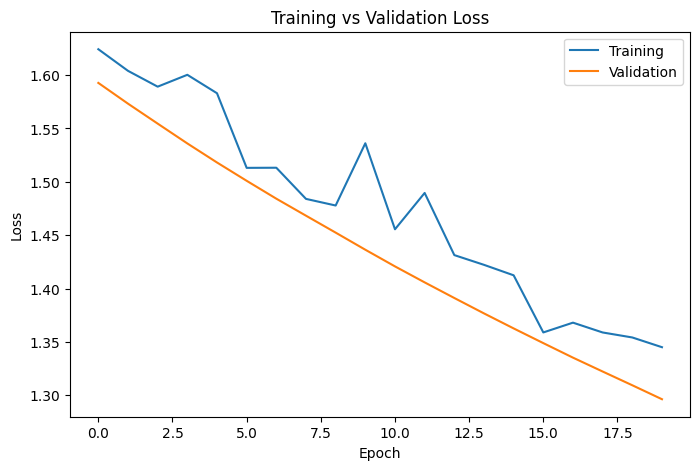

In [33]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training")

plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [34]:
# Save Kigali model

transfer_model.save(

    MODELS_DIR / "urban_noise_kigali.keras"

)

print("Kigali model saved successfully.")

Kigali model saved successfully.


In [35]:
# Save Kigali label encoder

import joblib

joblib.dump(

    encoder,

    MODELS_DIR / "label_encoder_kigali.pkl"

)

print("Label encoder saved.")

Label encoder saved.


In [36]:
print("="*60)
print("KIGALI MODEL COMPLETE")
print("="*60)

print(f"Classes       : {len(encoder.classes_)}")
print(f"Dataset Size  : {len(X)}")
print(f"Test Accuracy : {test_accuracy:.4f}")

print("\nClasses:")

for c in encoder.classes_:
    print("-", c)

print("\nArtifacts Produced")
print("-------------------")
print("urban_noise_kigali.keras")
print("label_encoder_kigali.pkl")
print("Confusion Matrix")
print("Classification Report")
print("Accuracy Curve")
print("Loss Curve")

KIGALI MODEL COMPLETE
Classes       : 5
Dataset Size  : 589
Test Accuracy : 0.4746

Classes:
- Ambience
- Constuction
- Entertainment
- Traffic
- Worship

Artifacts Produced
-------------------
urban_noise_kigali.keras
label_encoder_kigali.pkl
Confusion Matrix
Classification Report
Accuracy Curve
Loss Curve
